#                  Assignment Task / Project - Data Analytics in Python

#                Sales Data (PDA 4052) - One Time Sales and Marketing Ltd.


In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading / reading file
df_DA_Project = pd.read_excel('/content/Sales Data_PDA_4052.xlsx')

In [3]:
print("\n **Information of Dataset**")
df_DA_Project.info()


 **Information of Dataset**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1002 non-null   object
 1   Unnamed: 1  1002 non-null   object
 2   Unnamed: 2  1002 non-null   object
 3   Unnamed: 3  1002 non-null   object
 4   Unnamed: 4  1002 non-null   object
 5   Unnamed: 5  1002 non-null   object
 6   Unnamed: 6  1002 non-null   object
dtypes: object(7)
memory usage: 54.9+ KB


In [4]:
print("\n**Statistical Description of Dataset**\n")
df_DA_Project.describe(include='all')


**Statistical Description of Dataset**



,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
count,1002,1002,1002,1002,1002,1002,1002.00
unique,646,438,4,6,4,166,999.00
top,24132,C475,Peter,Critical,Plane,2020-08-15 00:00:00,177.23
freq,6,11,344,221,770,15,2.00


In [5]:
df_DA_Project.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
1,8999,C406,Kelly,High,Plane,2020-06-12 00:00:00,1553.44
2,47872,C100,Kelly,Critical,Plane,2020-06-12 00:00:00,315.4
3,29988,C006,Kelly,High,Lorry,2020-06-12 00:00:00,5075.89
4,37348,C492,Kelly,High,Plane,2020-06-13 00:00:00,520.67


In [6]:
df_DA_Project.tail()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
997,12258,C440,Pryia,Low,Plane,2020-11-30 00:00:00,2417.14
998,57061,C234,Pryia,Low,Plane,2020-11-30 00:00:00,451.18
999,57061,C234,Pryia,Low,Plane,2020-11-30 00:00:00,35.15
1000,57061,C234,Pryia,Low,Plane,2020-11-30 00:00:00,50.14
1001,36416,C691,Pryia,Low,Plane,2020-11-30 00:00:00,127.18


In [7]:
df_DA_Project.value_counts()

Unnamed: 0  Unnamed: 1   Unnamed: 2    Unnamed: 3     Unnamed: 4  Unnamed: 5           Unnamed: 6
order_id    customer_id  sales_person  priority       ship_mode   date                 value_£       1
224         C073         Kelly         Not Specified  Plane       2020-06-17 00:00:00  252.6         1
                         Pryia         Not Specified  Plane       2020-06-17 00:00:00  167.9         1
                                                                                       488.51        1
231         C688         Pryia         High           Plane       2020-09-28 00:00:00  682.91        1
                                                                                                    ..
1031        C677         Kelly         Medium         Plane       2020-08-31 00:00:00  216.58        1
998         C027         Kelly         Not Specified  Plane       2020-11-25 00:00:00  234.21        1
960         C379         Kelly         Medium         Plane       2020-09-20 00:00:00  587.37        1
902         C522         Peter         Not Specified  Plane       2020-07-26 00:00:00  1888.07       1
900         C420         Peter         Not Specified  Plane       2020-09-30 00:00:00  1105.23       1
Name: count, Length: 1002, dtype: int64

In [8]:
#Changed head as first row
df_DA_Project.columns = df_DA_Project.iloc[0]
df_DA_Project = df_DA_Project[1:].reset_index(drop=True)

In [9]:
print(f"\nThe names of columns in dataset are :\n \n{df_DA_Project.columns}")


The names of columns in dataset are :
 
Index(['order_id', 'customer_id', 'sales_person', 'priority', 'ship_mode',
       'date', 'value_£'],
      dtype='object', name=0)


In [10]:
#Changed Columns names
df_DA_Project = df_DA_Project.rename(columns={'order_id': 'Order_ID'})
df_DA_Project = df_DA_Project.rename(columns={'customer_id': 'Customer_ID'})
df_DA_Project = df_DA_Project.rename(columns={'sales_person': 'Sales_Person'})
df_DA_Project = df_DA_Project.rename(columns={'priority': 'Priority'})
df_DA_Project = df_DA_Project.rename(columns={'ship_mode': 'Shipment_Mode'})
df_DA_Project = df_DA_Project.rename(columns={'date': 'Date'})
df_DA_Project = df_DA_Project.rename(columns={'value_£': 'Sales_Amount'})

In [11]:
# Changed the Datatypes of 2 x columns

if 'Unnamed: 0' in df_DA_Project.columns:
    df_DA_Project.columns = df_DA_Project.iloc[0]
    df_DA_Project = df_DA_Project[1:].reset_index(drop=True)

if 'Sales_Amount' in df_DA_Project.columns:
    df_DA_Project['Sales_Amount'] = pd.to_numeric(df_DA_Project['Sales_Amount'], errors='coerce')
if 'Date' in df_DA_Project.columns:
    df_DA_Project['Date'] = pd.to_datetime(df_DA_Project['Date'], errors='coerce')

In [12]:
print(f"After handling Inconsistant Variables - Dataset is \n  ")
df_DA_Project.head()

After handling Inconsistant Variables - Dataset is 
  


,Order_ID,Customer_ID,Sales_Person,Priority,Shipment_Mode,Date,Sales_Amount
0,8999,C406,Kelly,High,Plane,2020-06-12,1553.44
1,47872,C100,Kelly,Critical,Plane,2020-06-12,315.40
2,29988,C006,Kelly,High,Lorry,2020-06-12,5075.89
3,37348,C492,Kelly,High,Plane,2020-06-13,520.67
4,28001,C231,Kelly,Critical,Plane,2020-06-14,8431.37


In [13]:
# Handling with missing values in the dataset

Total_Missing_Values = df_DA_Project.isnull().sum().sum()
print(f"Total Number of Missing Values in Dataset are: \n{Total_Missing_Values}\n")

#Percentage of missing values
Total_cells = np.prod(df_DA_Project.shape)
print(f"Total number of cells in Dataset are: \n{Total_cells}\n")

Percentage_Missing_Values = Total_Missing_Values/Total_cells * 100
print(f"Percentage of Missing values in Dataframe is: \n{Percentage_Missing_Values}% \n")

# If detected missing values, can be removed using dropna() to ensure analytical accuracy.

Total Number of Missing Values in Dataset are: 
0

Total number of cells in Dataset are: 
7007

Percentage of Missing values in Dataframe is: 
0.0% 



In [14]:
display(df_DA_Project.describe(include='all'))
df_DA_Project.isna().sum()

,Order_ID,Customer_ID,Sales_Person,Priority,Shipment_Mode,Date,Sales_Amount
count,1001.0,1001,1001,1001,1001,1001,1001.000000
unique,645.0,437,3,5,3,NaN,NaN
top,24132.0,C475,Peter,Critical,Plane,NaN,NaN
freq,6.0,11,344,221,770,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2020-09-04 08:03:21.398601216,1778.402248
min,NaN,NaN,NaN,NaN,NaN,2020-06-12 00:00:00,2.450000
25%,NaN,NaN,NaN,NaN,NaN,2020-07-26 00:00:00,134.400000
50%,NaN,NaN,NaN,NaN,NaN,2020-09-04 00:00:00,417.580000
75%,NaN,NaN,NaN,NaN,NaN,2020-10-15 00:00:00,1816.930000
max,NaN,NaN,NaN,NaN,NaN,2020-11-30 00:00:00,27448.240000


,0
0,
Order_ID,0
Customer_ID,0
Sales_Person,0
Priority,0
Shipment_Mode,0
Date,0
Sales_Amount,0


In [15]:
# Handling with Duplicate records

print(f"Total Duplicate rows in Dataset are: \n{df_DA_Project.duplicated().sum()}\n")

Total Duplicate rows in Dataset are: 
0



In [16]:
# For removing duplicate rows, if exist
Before_duplicate_Cmd = df_DA_Project.shape[0]
print(f"Before Handling Duplicates, Rows are: \n{Before_duplicate_Cmd}\n")

df_DA_Project = df_DA_Project.drop_duplicates()

After_duplicate_Cmd = df_DA_Project.shape[0]
print(f"Number of Dropped / Removed Duplicate Rows are:  \n{Before_duplicate_Cmd - After_duplicate_Cmd}\n")
print(f"After Removing Duplicates Rows are: \n{After_duplicate_Cmd}")

Before Handling Duplicates, Rows are: 
1001

Number of Dropped / Removed Duplicate Rows are:  
0

After Removing Duplicates Rows are: 
1001


In [17]:
#Outliers Handling
df_DA_Project2 = df_DA_Project.copy()

In [18]:
Q1 = df_DA_Project2['Sales_Amount'].quantile(0.25)
Q3 = df_DA_Project2['Sales_Amount'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Detect outliers
outliers = df_DA_Project2[(df_DA_Project2['Sales_Amount'] < lower_limit) | (df_DA_Project2['Sales_Amount'] > upper_limit)]
print(outliers)

0   Order_ID Customer_ID Sales_Person       Priority Shipment_Mode       Date  \
2      29988        C006        Kelly           High         Lorry 2020-06-12   
4      28001        C231        Kelly       Critical         Plane 2020-06-14   
5      53350        C730        Kelly  Not Specified         Plane 2020-06-14   
13      9954        C741        Kelly  Not Specified         Lorry 2020-06-19   
35     41216        C434        Kelly  Not Specified         Lorry 2020-07-01   
..       ...         ...          ...            ...           ...        ...   
962     4931        C307        Pryia       Critical         Plane 2020-11-16   
968    15139        C318        Pryia           High         Lorry 2020-11-19   
975    48295        C120        Pryia         Medium         Plane 2020-11-23   
978     3492        C660        Pryia            Low         Lorry 2020-11-23   
994    37924        C613        Pryia           High         Plane 2020-11-29   

0    Sales_Amount  
2      

In [19]:
# Counting and Printing Total outliers in Dataset
Total_outliers = outliers.shape[0]

print(f"\n Total outliers in Sales Amount Column are: {Total_outliers}")

percentage_of_Total_outliers = (Total_outliers / df_DA_Project.shape[0]) * 100
print(f"\n Percentage of Total outliers in Sales Amount Column are: {percentage_of_Total_outliers:.2f}%")


 Total outliers in Sales Amount Column are: 122

 Percentage of Total outliers in Sales Amount Column are: 12.19%


/tmp/ipykernel_6047/3858728369.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=df_DA_Project['Sales_Amount'], palette='viridis',kde=True, bins=40)


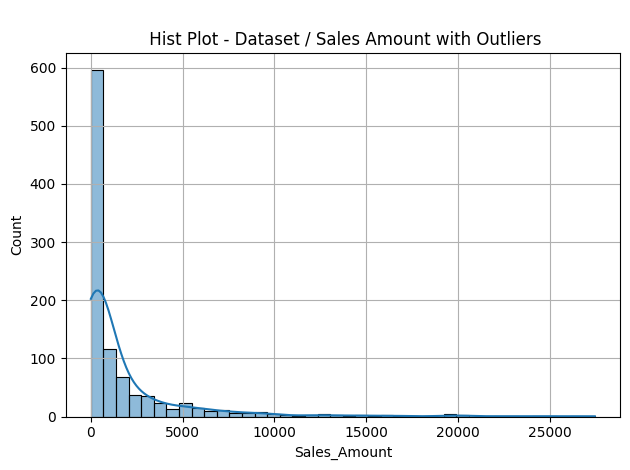

/tmp/ipykernel_6047/3858728369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_DA_Project['Sales_Amount'], palette='viridis')


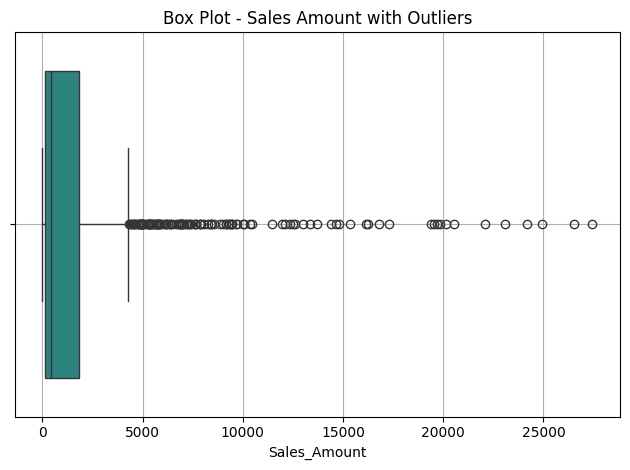

In [20]:
# Dataset Visualisation with Outliers
sns.histplot(x=df_DA_Project['Sales_Amount'], palette='viridis',kde=True, bins=40)
plt.title("\n Hist Plot - Dataset / Sales Amount with Outliers")
plt.grid()
plt.tight_layout()
plt.savefig('Hist Plot - Dataset - Sales Amount with Outliers.png', dpi=1000)
plt.show()

sns.boxplot(x=df_DA_Project['Sales_Amount'], palette='viridis')
plt.title("Box Plot - Sales Amount with Outliers")
plt.grid()
plt.tight_layout()
plt.savefig('Box Plot - Dataset - Sales Amount with Outliers.png', dpi=1000)
plt.show()

In [21]:
# Removing outliers from the Dataset
df_DA_Project_no_outliers = df_DA_Project2[(df_DA_Project2['Sales_Amount'] >= lower_limit) & (df_DA_Project2['Sales_Amount'] <= upper_limit)]

print(f"\nOriginal Dataset Shape / Fields Records:  Rows = {df_DA_Project.shape[0]} , Columns = {df_DA_Project.shape[1]}\n")

print(f"Total outliers in Sales Amount Column are: {Total_outliers}\n")

print(f"Dataframe Shape / Fields Records after removing outliers:  Rows = {df_DA_Project_no_outliers.shape[0]} , Columns = {df_DA_Project.shape[1]} ")

percentage_outliers_removed = (Total_outliers / Before_duplicate_Cmd) * 100
print(f"\nPercentage of total outliers removed: {percentage_outliers_removed:.2f}%")


Original Dataset Shape / Fields Records:  Rows = 1001 , Columns = 7

Total outliers in Sales Amount Column are: 122

Dataframe Shape / Fields Records after removing outliers:  Rows = 879 , Columns = 7 

Percentage of total outliers removed: 12.19%


/tmp/ipykernel_6047/4095939082.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=df_DA_Project_no_outliers['Sales_Amount'], palette='viridis',kde=True, bins=40)


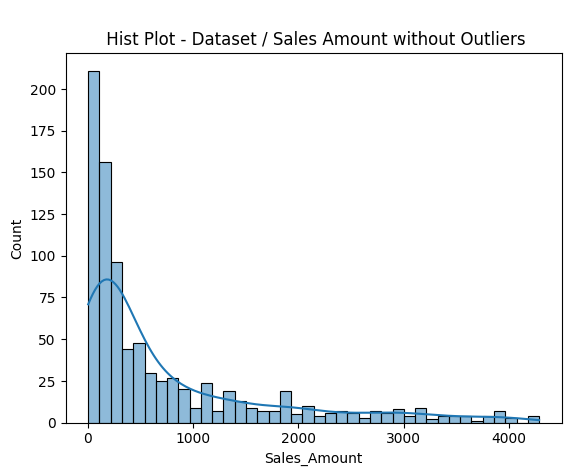

/tmp/ipykernel_6047/4095939082.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_DA_Project_no_outliers['Sales_Amount'], palette='viridis')


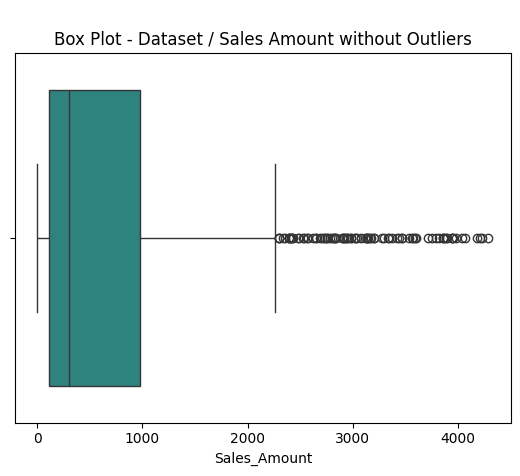

In [22]:
# Dataset Visualisation without Outliers
sns.histplot(x=df_DA_Project_no_outliers['Sales_Amount'], palette='viridis',kde=True, bins=40)
plt.title("\n Hist Plot - Dataset / Sales Amount without Outliers")
plt.savefig('Hist Plot - Dataset - Sales Amount without Outliers.png', dpi=1000)
plt.show()

sns.boxplot(x=df_DA_Project_no_outliers['Sales_Amount'], palette='viridis')
plt.title("\nBox Plot - Dataset / Sales Amount without Outliers")
plt.savefig('Box Plot - Dataset - Sales Amount without Outliers.png', dpi=1000)
plt.show()

In [23]:
df_DA_Project.describe(include='all')

,Order_ID,Customer_ID,Sales_Person,Priority,Shipment_Mode,Date,Sales_Amount
count,1001.0,1001,1001,1001,1001,1001,1001.000000
unique,645.0,437,3,5,3,NaN,NaN
top,24132.0,C475,Peter,Critical,Plane,NaN,NaN
freq,6.0,11,344,221,770,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2020-09-04 08:03:21.398601216,1778.402248
min,NaN,NaN,NaN,NaN,NaN,2020-06-12 00:00:00,2.450000
25%,NaN,NaN,NaN,NaN,NaN,2020-07-26 00:00:00,134.400000
50%,NaN,NaN,NaN,NaN,NaN,2020-09-04 00:00:00,417.580000
75%,NaN,NaN,NaN,NaN,NaN,2020-10-15 00:00:00,1816.930000
max,NaN,NaN,NaN,NaN,NaN,2020-11-30 00:00:00,27448.240000


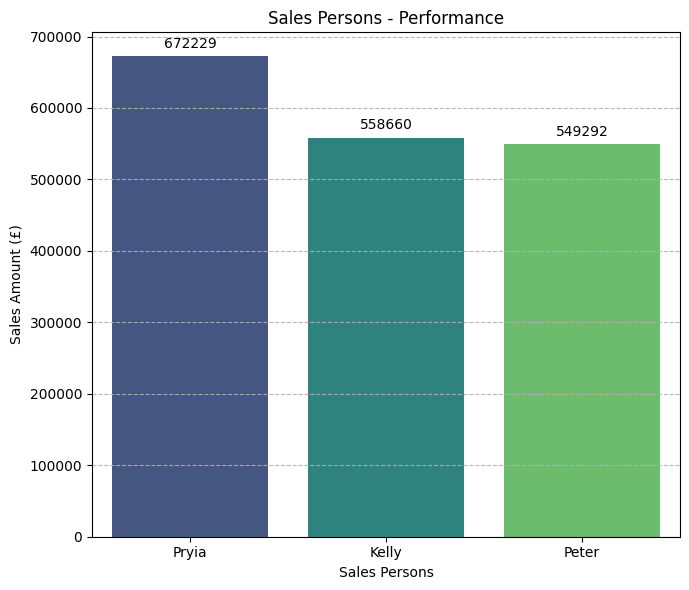

In [24]:
# Sales Persons Performance Analysis
Salesperson_Performance = df_DA_Project.groupby('Sales_Person')['Sales_Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 6))
ax = sns.barplot(x=Salesperson_Performance.index, y=Salesperson_Performance.values, hue=Salesperson_Performance.index, palette='viridis', legend=False)
plt.title('Sales Persons - Performance')
plt.xlabel('Sales Persons')
plt.ylabel('Sales Amount (£)')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),  textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.savefig('Sales Persons - Performance.png', dpi=1000)
plt.show()

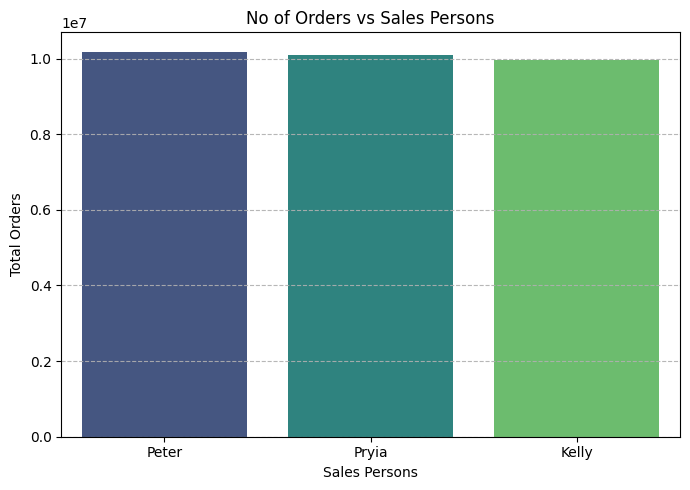

In [25]:
# No of Orders vs Sales Persons Analysis
Total_Orders_by_salesperson = df_DA_Project.groupby(['Sales_Person'])['Order_ID'].sum().reset_index().sort_values(by='Order_ID', ascending=False)
plt.figure(figsize=(7, 5))
sns.barplot(x='Sales_Person', y='Order_ID', hue='Sales_Person', data=Total_Orders_by_salesperson, palette='viridis', legend=False)
plt.title('No of Orders vs Sales Persons')
plt.xlabel('Sales Persons')
plt.ylabel('Total Orders')
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.savefig('No of Orders vs Sales Persons.png', dpi=1000)
plt.show()

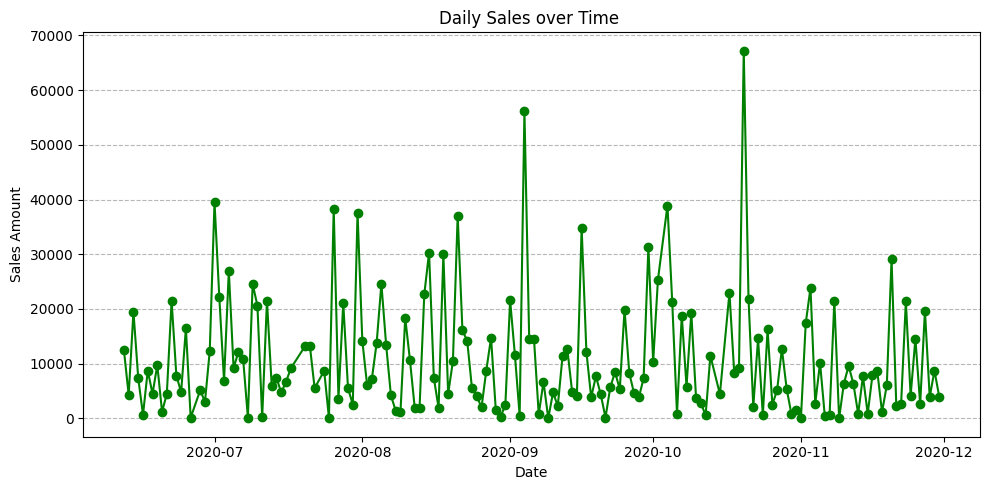

In [26]:
# Daily Sales Analysis Over Time
Daily_Sales = df_DA_Project.groupby('Date')['Sales_Amount'].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(Daily_Sales['Date'], Daily_Sales['Sales_Amount'], marker='o',color='green')
plt.title('Daily Sales over Time ')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.savefig('Daily Sales over Time.png', dpi=1000)
plt.show()

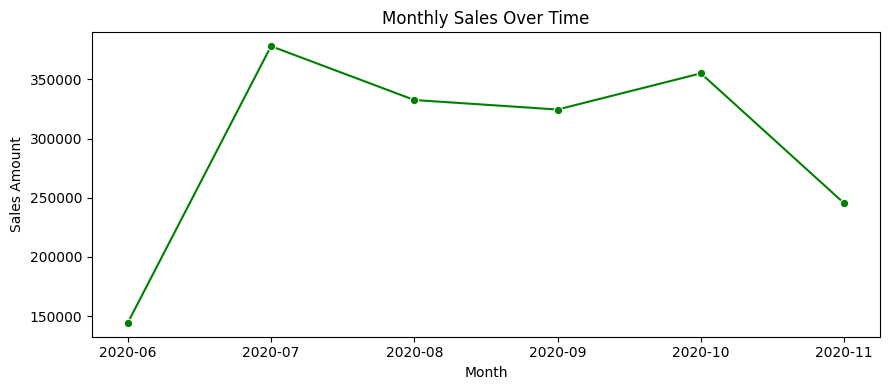

In [27]:
# Monthly Sales Analysis Over Time
df_DA_Project['year_month'] = df_DA_Project['Date'].dt.to_period('M')
Monthly_Sales = df_DA_Project.groupby('year_month')['Sales_Amount'].sum().reset_index()
Monthly_Sales['year_month'] = Monthly_Sales['year_month'].astype(str)
plt.figure(figsize=(9, 4))
sns.lineplot(data=Monthly_Sales, x='year_month', y='Sales_Amount', marker='o', color='green')
plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.savefig('Monthly Sales Over Time.png', dpi=1000)
plt.show()

/tmp/ipykernel_6047/3913389654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_DA_Project, x='Priority', y='Sales_Amount', order=order, palette='viridis')


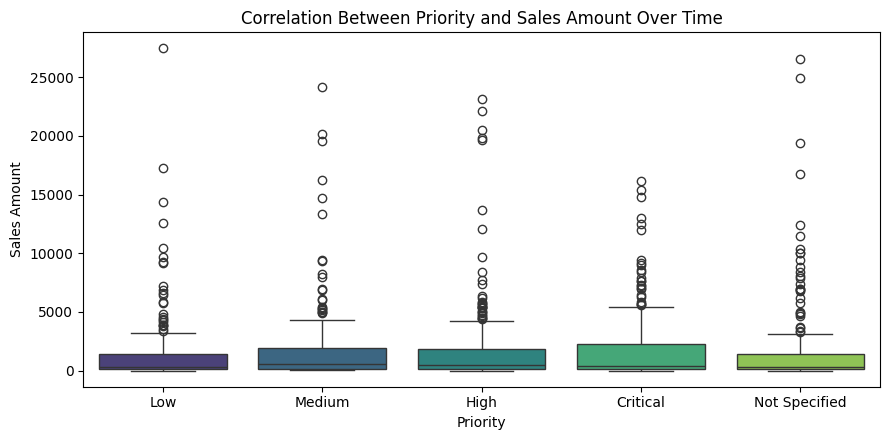

In [28]:
#Correlation of Priority and Sales Amount Over Time in the Dataset
plt.figure(figsize=(9, 4.5))
order = [ 'Low', 'Medium', 'High', 'Critical','Not Specified']
sns.boxplot(data=df_DA_Project, x='Priority', y='Sales_Amount', order=order, palette='viridis')
plt.title('Correlation Between Priority and Sales Amount Over Time')
plt.xlabel('Priority')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.savefig('Correlation Between Priority and Sales Amount Over Time.png', dpi=1000)
plt.show()

In [29]:
priority_stats = df_DA_Project.groupby('Priority')['Sales_Amount'].agg(['count', 'mean', 'sum']).loc[order]
priority_stats

,count,mean,sum
Priority,,,
Low,200,1462.679050,292535.81
Medium,171,1931.797485,330337.37
High,196,1946.650000,381543.40
Critical,221,1826.481131,403652.33
Not Specified,213,1747.003474,372111.74


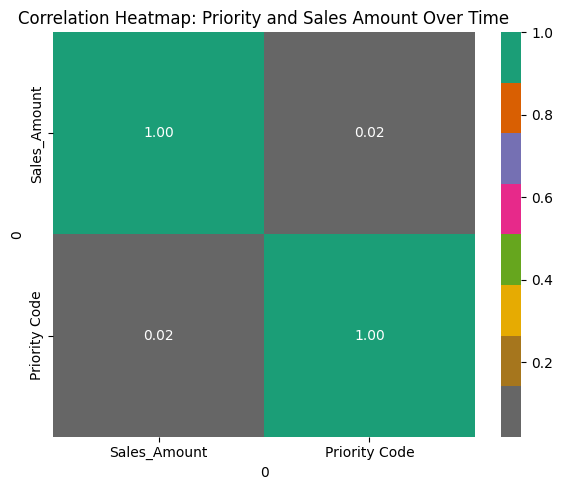

In [30]:
#Correlation of Priority and Sales Amount Over Time in the Dataset

Priority_vs_Sales = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3, 'Not Specified': 4}
df_DA_Project['Priority Code'] = df_DA_Project['Priority'].map(Priority_vs_Sales)

correlation_sales_priority = df_DA_Project[['Sales_Amount', 'Priority Code']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_sales_priority, annot=True, cmap='Dark2_r', fmt=".2f")
plt.title('Correlation Heatmap: Priority and Sales Amount Over Time')
plt.tight_layout()
plt.savefig('Correlation Heatmap: Priority and Sales Amount Over Time.png', dpi=1000)
plt.show()